In [8]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv("Concrete_Data_Yeh.csv")

Data Understanding

In [10]:
df.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [11]:
df.sample(10)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
58,304.0,76.0,0.0,228.0,0.0,932.0,670.0,180,50.95
308,277.1,0.0,97.4,160.6,11.8,973.9,875.6,100,55.64
611,277.0,0.0,0.0,191.0,0.0,968.0,856.0,14,21.26
261,212.6,0.0,100.4,159.4,10.4,1003.8,903.8,28,37.40
743,397.0,0.0,0.0,186.0,0.0,1040.0,734.0,28,36.94
784,331.0,0.0,0.0,192.0,0.0,879.0,825.0,3,13.52
305,277.1,0.0,97.4,160.6,11.8,973.9,875.6,14,41.89
697,108.3,162.4,0.0,203.5,0.0,938.2,849.0,7,7.72
520,284.0,15.0,141.0,179.0,5.5,842.0,801.0,3,13.40
1018,321.4,0.0,127.9,182.5,11.5,870.1,779.7,28,37.27


In [12]:
df.shape

(1030, 9)

In [13]:
df.duplicated().sum()

np.int64(25)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(1005, 9)

In [16]:
df.isnull().sum()

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

In [17]:
df.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1005 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1005 non-null   float64
 1   slag              1005 non-null   float64
 2   flyash            1005 non-null   float64
 3   water             1005 non-null   float64
 4   superplasticizer  1005 non-null   float64
 5   coarseaggregate   1005 non-null   float64
 6   fineaggregate     1005 non-null   float64
 7   age               1005 non-null   int64  
 8   csMPa             1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 78.5 KB


In [19]:
num_cols = df.select_dtypes(include=["int64","float64"]).drop(columns=["csMPa"]).columns
tar_col = df["csMPa"]

EDA

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

Univariate Analysis

num cols

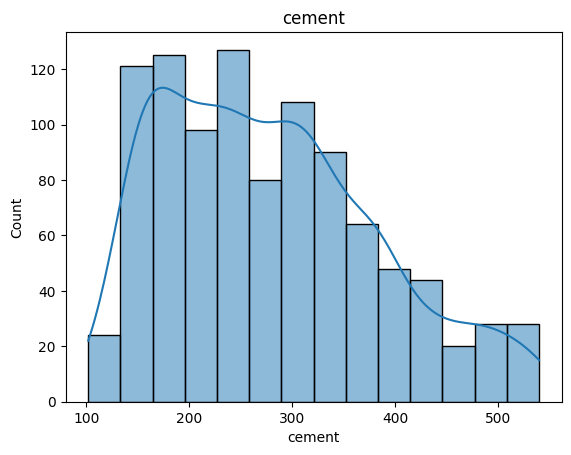

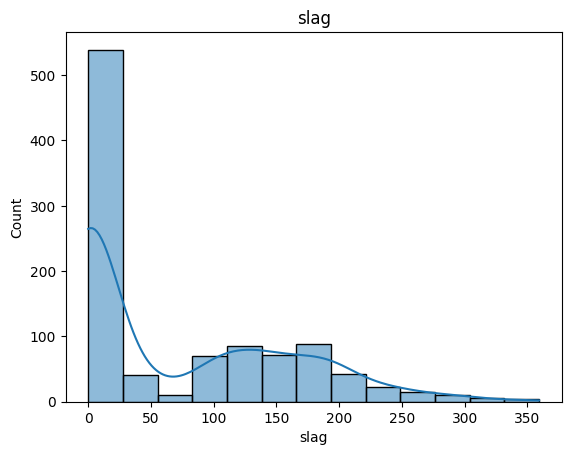

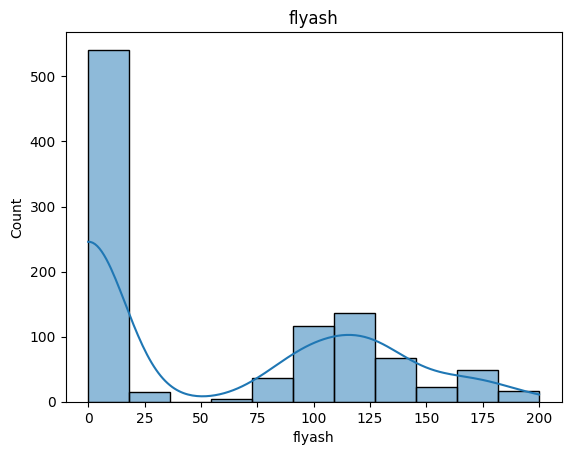

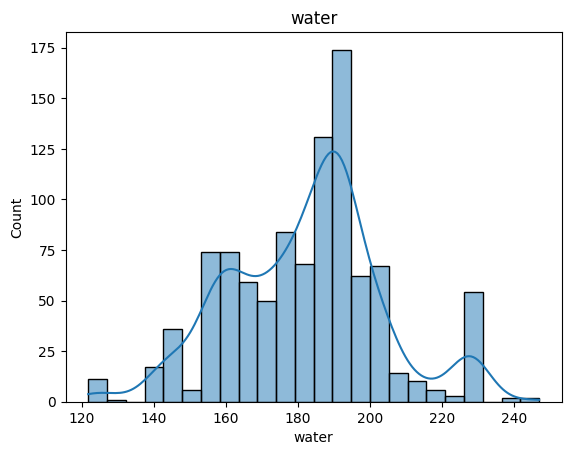

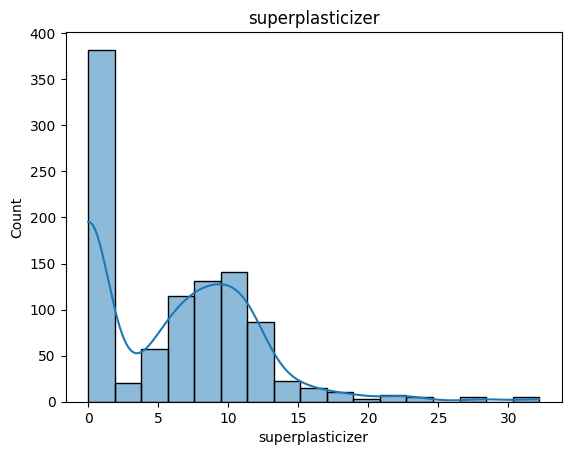

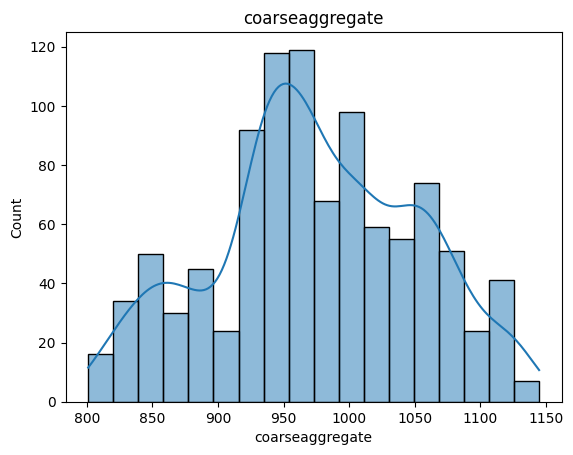

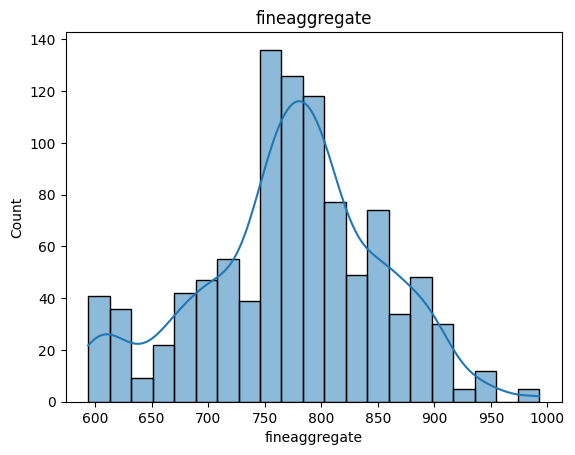

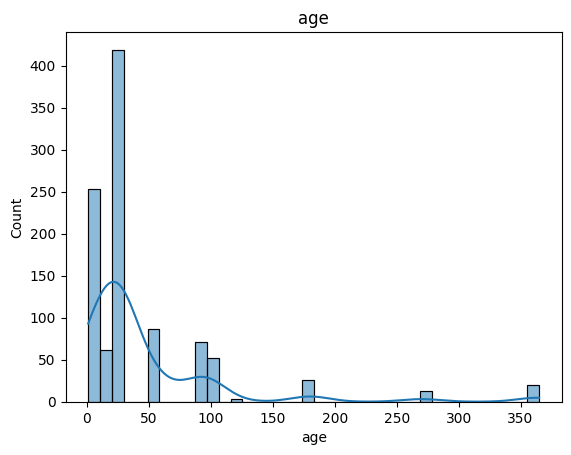

In [21]:
for col in num_cols:
    sns.histplot(x=col,data=df,kde=True)
    plt.title(col)
    plt.show()

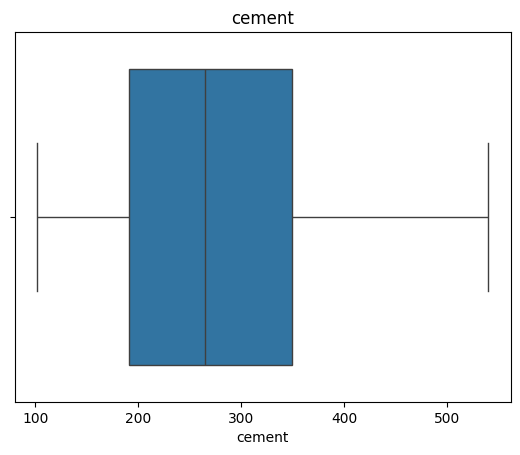

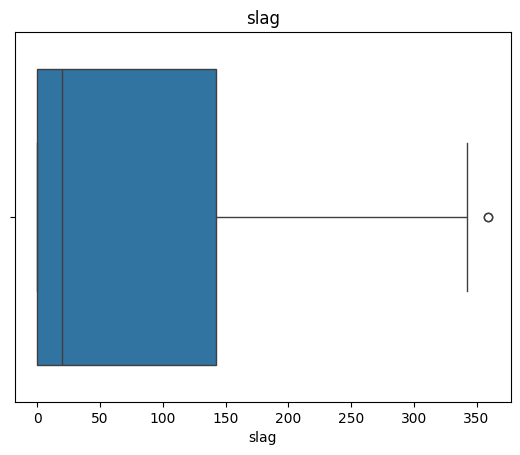

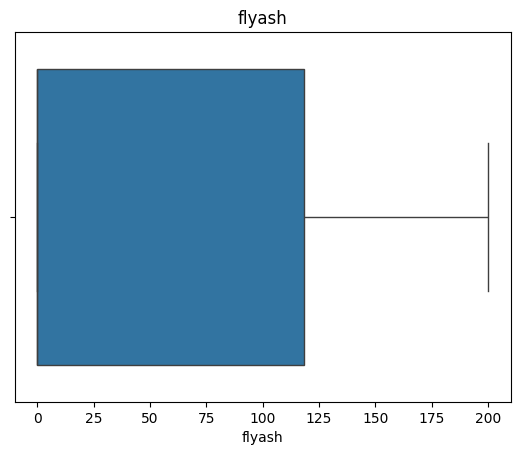

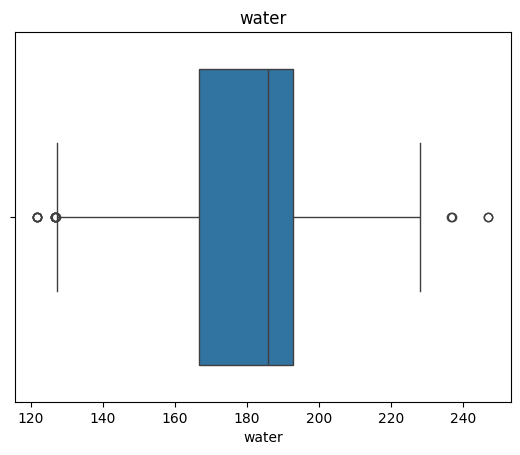

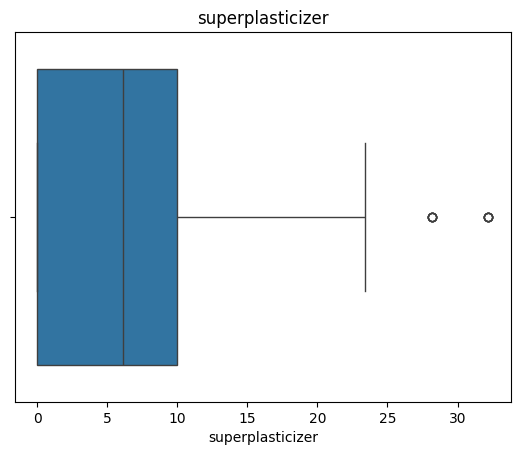

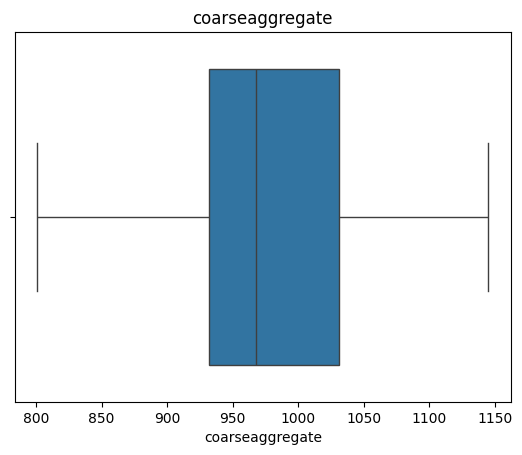

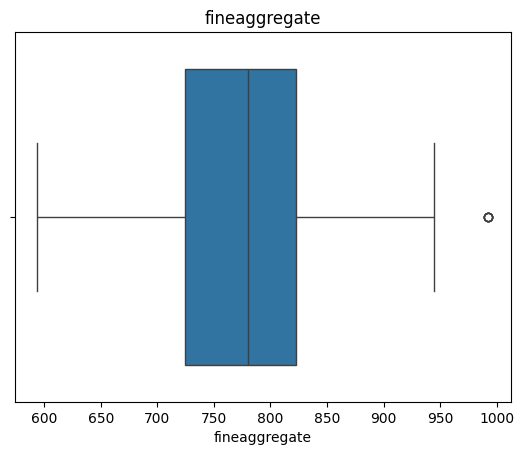

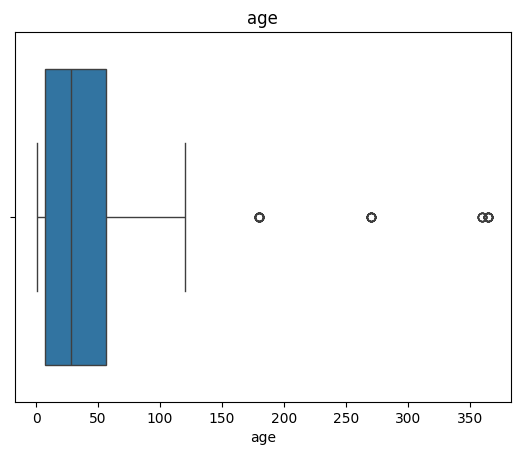

In [22]:
for col in num_cols:
    sns.boxplot(x=col,data=df)
    plt.title(col)
    plt.show()

Target col

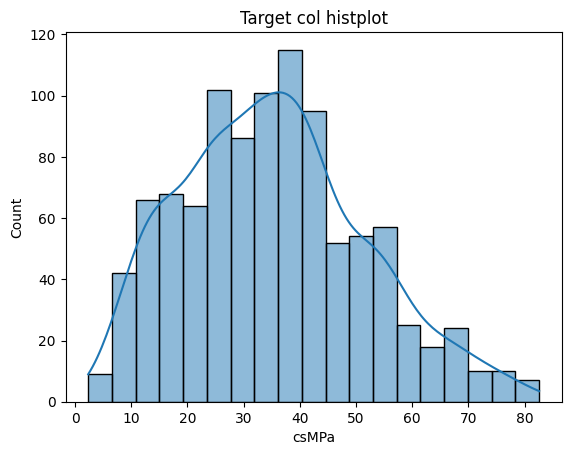

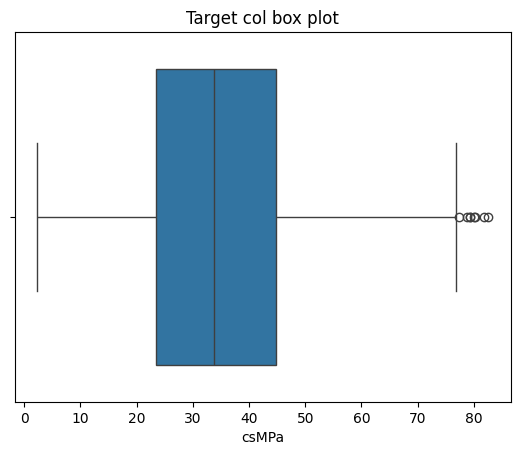

In [23]:
sns.histplot(x=tar_col,data=df,kde=True)
plt.title("Target col histplot")
plt.show()
sns.boxplot(x=tar_col,data=df)
plt.title("Target col box plot")
plt.show()

Bivariate Analysis

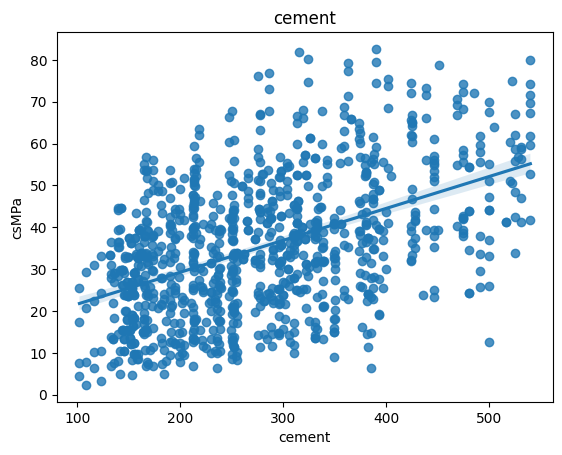

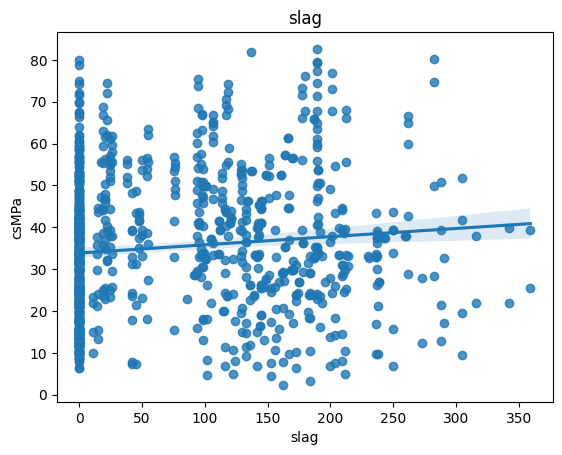

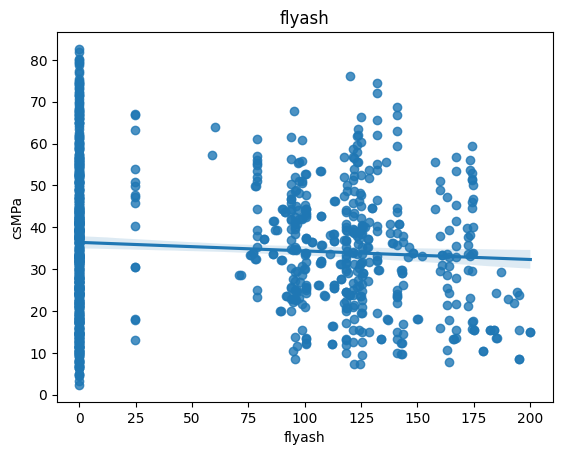

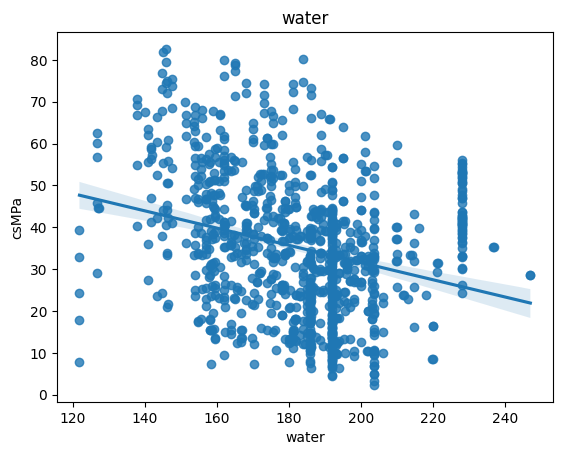

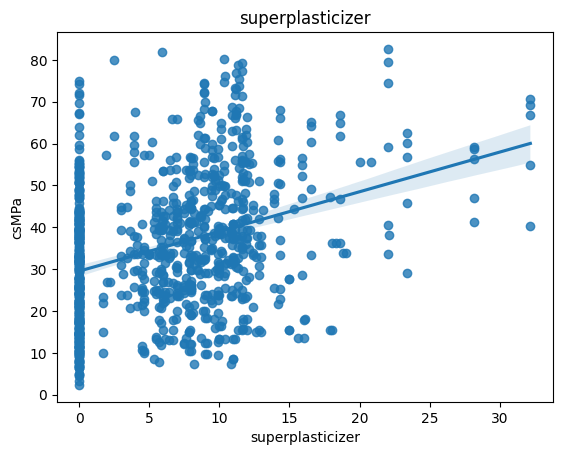

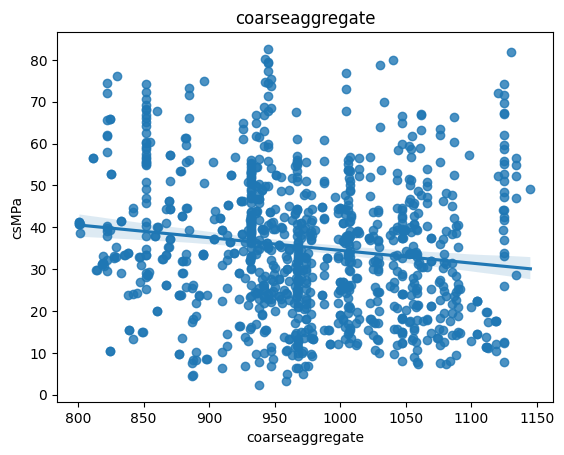

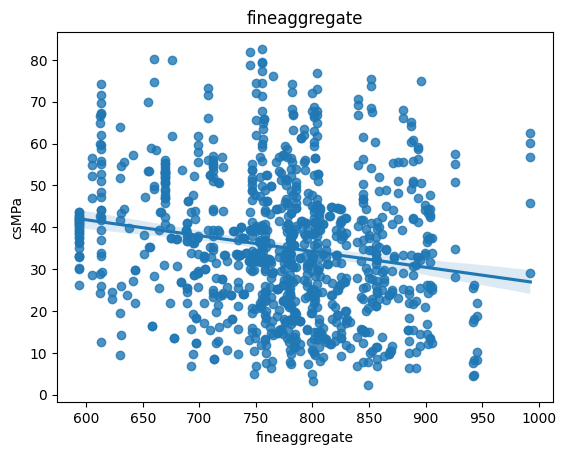

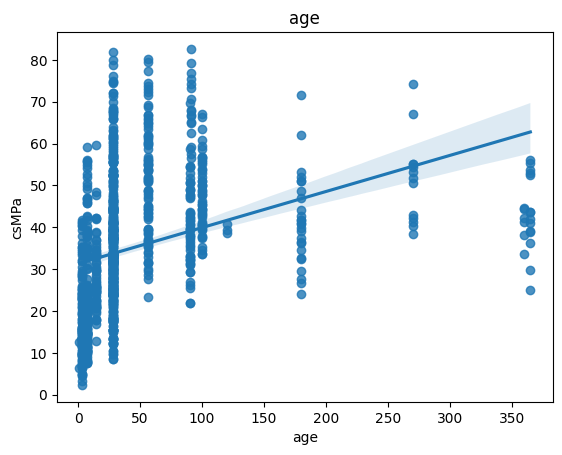

In [24]:
for col in num_cols:
    sns.regplot(x=col,y=tar_col,data=df)
    plt.title(col)
    plt.show()

Multivariate Analysis

<Axes: >

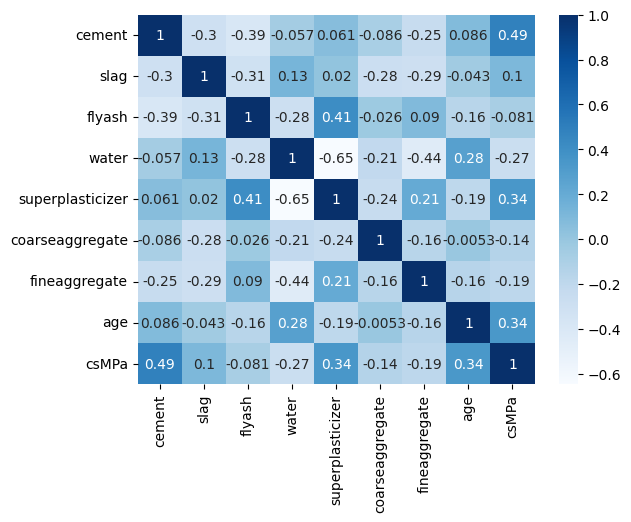

In [25]:
sns.heatmap(df.corr(),annot=True,cmap="Blues")

Preprocessing

In [26]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error,r2_score
import optuna

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
from outliers_handler import outliers_handling

In [28]:
df.sample(1)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
830,162.0,190.0,148.0,179.0,19.0,838.0,741.0,28,33.76


In [29]:
x = df.drop(columns=["csMPa"])
y = df["csMPa"]

In [65]:
x.columns

Index(['cement', 'slag', 'flyash', 'water', 'superplasticizer',
       'coarseaggregate', 'fineaggregate', 'age'],
      dtype='object')

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
num_pipeline = Pipeline(steps=[
    ("outliers_handling",outliers_handling()),
    ("scaling",StandardScaler())
])

In [33]:
preprocessing = ColumnTransformer(transformers=[
    ("num_pipeline",num_pipeline,num_cols)
])

In [34]:
def objective(trial):
    model_name = trial.suggest_categorical("regressor", ["lr", "dt", "rf", "xgb"])

    if model_name == "lr":
        model = LinearRegression()

    elif model_name == "dt":
        model = DecisionTreeRegressor(
        max_depth=trial.suggest_int("max_depth", 3, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10)
    )

    elif model_name == "rf":
        model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        max_depth=trial.suggest_int("max_depth", 5, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        n_jobs=-1
    )

    elif model_name == "xgb":
        model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        reg_alpha=trial.suggest_float("reg_alpha", 0, 5),
        reg_lambda=trial.suggest_float("reg_lambda", 0, 5),
        n_jobs=-1,
        verbosity=0
    )

    pipe = Pipeline(steps=[
        ("preprocessing",preprocessing),
        ("model",model)
    ])
    score = cross_val_score(pipe,x_train,y_train,cv=5,scoring="neg_root_mean_squared_error")
    return score.mean()

In [35]:
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=100)

[I 2026-05-25 22:06:03,795] A new study created in memory with name: no-name-7b789658-2e72-4dfd-91d7-78acb05f6461
[I 2026-05-25 22:06:05,158] Trial 0 finished with value: -6.328839011007867 and parameters: {'regressor': 'rf', 'n_estimators': 139, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': None}. Best is trial 0 with value: -6.328839011007867.
[I 2026-05-25 22:06:05,289] Trial 1 finished with value: -7.3188284368874985 and parameters: {'regressor': 'dt', 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: -6.328839011007867.
[I 2026-05-25 22:06:05,410] Trial 2 finished with value: -8.703677597043816 and parameters: {'regressor': 'dt', 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 4}. Best is trial 0 with value: -6.328839011007867.
[I 2026-05-25 22:06:10,053] Trial 3 finished with value: -5.142094176501297 and parameters: {'regressor': 'xgb', 'n_estimators': 390, 'learning_rate': 0.01451065817231

In [37]:
params = study.best_params
model_name = params["regressor"]

if model_name == "lr":
    final_model = LinearRegression()

elif model_name == "dt":
    final_model = DecisionTreeRegressor(
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"]
    )

elif model_name == "rf":
    final_model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        n_jobs=-1
    )

elif model_name == "xgb":
    final_model = XGBRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        n_jobs=-1,
        verbosity=0
    )

In [38]:
final_pipeline = Pipeline(steps=[
    ("preprocessing",preprocessing),
    ("final_model",final_model)
])

In [39]:
final_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('outliers_handling',
                                                                   outliers_handling()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  Index(['cement', 'slag', 'flyash', 'water', 'superplasticizer',
       'coarseaggregate', 'fineaggregate', 'age'],
      dtype='object'))])),
                ('final_model',
                 XGBRegressor(base_score=None, booster=None, cal...
                              gamma=0.2884691354879321, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.1850302569520559, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=465, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [40]:
y_train_pred = final_pipeline.predict(x_train)
y_test_pred = final_pipeline.predict(x_test)

In [41]:
train_rmse = root_mean_squared_error(y_train,y_train_pred)
print(f"Train RMSE: {train_rmse}")
test_rmse = root_mean_squared_error(y_test,y_test_pred)
print(f"Test RMSE: {test_rmse}")

Train RMSE: 1.5593083634462876
Test RMSE: 4.423626741493788


In [42]:
train_r2 = r2_score(y_train,y_train_pred)
print(f"Train r2: {train_r2}")
test_r2 = r2_score(y_test,y_test_pred)
print(f"Test r2: {test_r2}")

Train r2: 0.9905175408359866
Test r2: 0.934405494720088


In [43]:
train_nrmse_range = train_rmse/(y_train.max()-y_train.min())
print(f"Train NRMSE Range: {train_nrmse_range}")
test_nrmse_range = test_rmse/(y_test.max()-y_test.min())
print(f"Test NRMSE Range: {test_nrmse_range}")

Train NRMSE Range: 0.020337920483191437
Test NRMSE Range: 0.055109340245344314


In [44]:
train_nrmse_mean = train_rmse/y_train.mean()
print(f"Train NRMSE mean: {train_nrmse_mean}")
test_nrmse_mean = test_rmse/y_test.mean()
print(f"Test NRMSE mean: {test_nrmse_mean}")

Train NRMSE mean: 0.04446657424263857
Test NRMSE mean: 0.12293322554263386


In [45]:
train_nrmse_std = train_rmse/y_train.std()
print(f"Train NRMSE std: {train_nrmse_std}")
test_nrmse_std = test_rmse/y_test.std()
print(f"Test NRMSE std: {test_nrmse_std}")

Train NRMSE std: 0.09731734203406647
Test NRMSE std: 0.2554763481374035


Model Explainability

In [49]:
import shap

In [46]:
shap_preprocessing = final_pipeline.named_steps["preprocessing"]
shap_model = final_pipeline.named_steps["final_model"]

In [47]:
shap_feature_names = []
for col in shap_preprocessing.get_feature_names_out():
    shap_feature_names.append(col.split("__")[-1])

In [58]:
x_train_t = pd.DataFrame(
    shap_preprocessing.transform(x_train),
    columns = shap_feature_names
)
x_test_t = pd.DataFrame(
    shap_preprocessing.transform(x_test),
    columns = shap_feature_names
)

In [59]:
explainer = shap.TreeExplainer(shap_model)

In [60]:
shap_values = explainer(x_test_t)

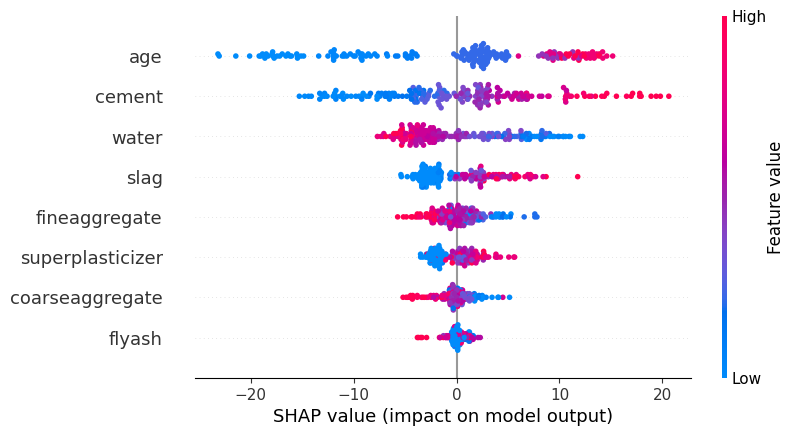

In [61]:
shap.plots.beeswarm(shap_values)

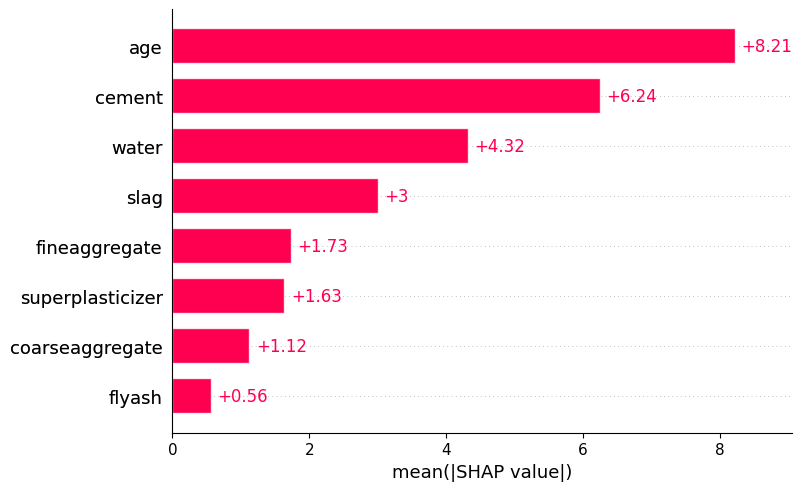

In [62]:
shap.plots.bar(shap_values)

Saving Required data

In [54]:
import joblib

In [64]:
joblib.dump(final_pipeline,"final_pipeline.pkl")

['final_pipeline.pkl']

In [63]:
joblib.dump(shap_feature_names,"shap_feature_names.pkl")

['shap_feature_names.pkl']